# Football Player Evaluation Model - Full Pipeline

This notebook contains the complete pipeline for training and evaluating the football player evaluation model.

## 0. Setup - Imports and Configuration

In [23]:

import time
import pandas as pd

import config
from src.analysis.prediction_utils import matches_info_df
from src.data.data_loader import load_statsbomb_socceraction_data
from src.data.data_splitter import split_matches
from src.ml.models.model_factory import create_model
from src.ml.preprocessing.sequence import SequencePreprocessor
from src.ml.train import ModelTrainer
from src.ml.xthreat import get_default_xt_model
from src.analysis.game_utils import game_summary

In [16]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [3]:
data = load_statsbomb_socceraction_data("data/statsbomb/data", 55, 282)
train_matches, val_matches, test_matches = split_matches(data)

print(f"Train matches: {len(train_matches)}, Validation matches: {len(val_matches)}, Test matches: {len(test_matches)}")

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

## 2. Preprocessing Data

#### Initialize preprocessor with sequence length and xT model

In [28]:
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

#### Process training, validation, and test sets

In [29]:
X_train, y_train, p_train, m_train = preprocessor.process_matches(train_matches)
X_val, y_val, p_val, m_val = preprocessor.process_matches(val_matches)
X_test, y_test, p_test, m_test = preprocessor.process_matches(test_matches)

→Processing match 3930178: 4006 events
 → Generated 104 sequences, 104 labels for match 3930178
→Processing match 3930181: 3688 events
 → Generated 83 sequences, 83 labels for match 3930181
→Processing match 3930184: 2953 events
 → Generated 90 sequences, 90 labels for match 3930184
→Processing match 3930167: 3721 events
 → Generated 108 sequences, 108 labels for match 3930167
→Processing match 3938643: 3767 events
 → Generated 110 sequences, 110 labels for match 3938643
→Processing match 3942819: 3485 events
 → Generated 82 sequences, 82 labels for match 3942819
→Processing match 3930170: 3552 events
 → Generated 94 sequences, 94 labels for match 3930170
→Processing match 3930179: 3776 events
 → Generated 104 sequences, 104 labels for match 3930179
→Processing match 3938641: 3400 events
 → Generated 113 sequences, 113 labels for match 3938641
→Processing match 3930159: 3356 events
 → Generated 109 sequences, 109 labels for match 3930159
→Processing match 3930175: 3200 events
 → Genera

#### Display dataset sizes

In [30]:
print(f"Train set: {X_train.shape[0]} sequences with shape {X_train.shape}")
print(f"Val set: {X_val.shape[0]} sequences with shape {X_val.shape}")
print(f"Test set: {X_test.shape[0]} sequences with shape {X_test.shape}")

Train set: 3755 sequences with shape (3755, 6, 45)
Val set: 962 sequences with shape (962, 6, 45)
Test set: 560 sequences with shape (560, 6, 45)


## 3. Build Model

In [7]:
model = create_model(
    config.MODEL_TYPE,
    input_shape=(config.SEQUENCE_LENGTH, X_train.shape[2])
)

# Display model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 6, 45)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 256)         │       178,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_weights               │ [(None, 128), (None,   │           134 │
│ (AttentionLayer)                │ 6)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ value (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 383,751 (1.46 MB)

 Trainable params: 383,751 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train Model

#### Initialize trainer and train the model

In [8]:
trainer = ModelTrainer(model)
trainer.train(
    X_train, y_train,
    X_val, y_val,
    batch_size=config.BATCH_SIZE,
    epochs=config.EPOCHS
)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - attention_weights_loss: 0.0278 - loss: 0.0033 - value_loss: 0.0033 - value_mae: 0.0275 - val_attention_weights_loss: 0.0278 - val_loss: 0.0026 - val_value_loss: 0.0025 - val_value_mae: 0.0274 - learning_rate: 0.0010
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - attention_weights_loss: 0.0278 - loss: 0.0024 - value_loss: 0.0024 - value_mae: 0.0214 - val_attention_weights_loss: 0.0278 - val_loss: 0.0023 - val_value_loss: 0.0022 - val_value_mae: 0.0196 - learning_rate: 0.0010
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - attention_weights_loss: 0.0279 - loss: 0.0023 - value_loss: 0.0023 - value_mae: 0.0211 - val_attention_weights_loss: 0.0279 - val_loss: 0.0023 - val_value_loss: 0.0022 - val_value_mae: 0.0200 - learning_rate: 0.0010
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - attention_weights_loss: 0.0280 - loss: 0.0022 - value_loss: 0.0022 - value_mae: 0.0206 - val_attention_weights_loss: 0.0280 - val_lo

## 5. Evaluate Model

#### Evaluate on validation and test sets

In [9]:
val_metrics = trainer.evaluate(X_val, y_val)
test_metrics = trainer.evaluate(X_test, y_test)

all_metrics = {
    'validation': val_metrics,
    'test': test_metrics
}

print(f"Validation Metrics: {val_metrics}")
print(f"Test Metrics: {test_metrics}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Test Results:
  test_loss: 0.0019
  test_mae: 0.0019
  test_rmse: 0.0436
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Test Results:
  test_loss: 0.0014
  test_mae: 0.0014
  test_rmse: 0.0370
Validation Metrics: {'test_loss': 0.0018994506681337953, 'test_mae': 0.0018766253488138318, 'test_rmse': 0.04358268689283328}
Test Metrics: {'test_loss': 0.001365790842100978, 'test_mae': 0.0013793427497148514, 'test_rmse': 0.03695661099629898}


## 6. Summary and Results

#### Save training metrics and plots

Metrics saved to models/attention_lstm/metrics.json


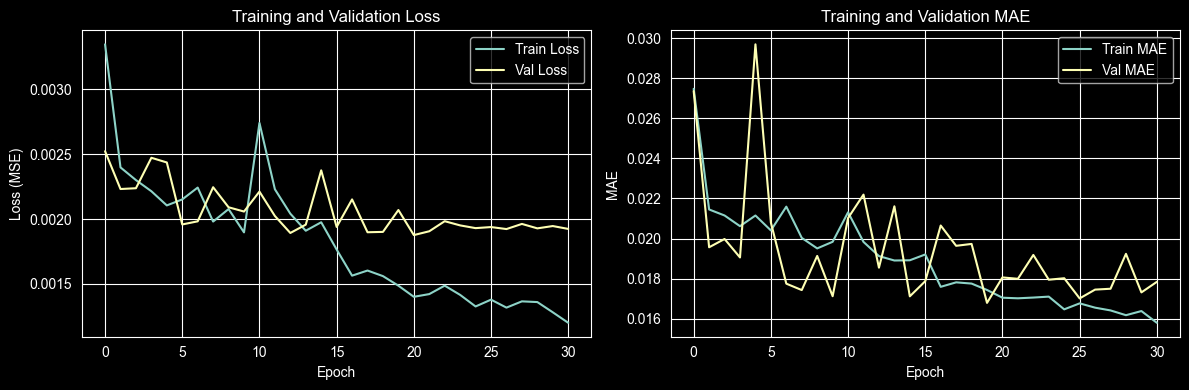

Pipeline completed successfully!
Best model saved as: models/attention_lstm/best_model.keras


In [10]:
trainer.save_training_metrics(all_metrics)
trainer.plot_training_history(filename="training_history.png")

print("Pipeline completed successfully!")
print(f"Best model saved as: models/{config.MODEL_TYPE}/best_model.keras")

## 7. Analysis

#### Extract match information from validation set

In [25]:
val_matches_df = matches_info_df(val_matches)
val_matches_df

,match_id,summary,events_count
0,3930166,Portugal 2 : 1 Czech Republic (Group Stage) [1...,3602
1,3930165,Austria 0 : 1 France (Group Stage) [17.06.2024],3718
2,3938645,Ukraine 0 : 0 Belgium (Group Stage) [26.06.2024],3525
3,3938637,Poland 1 : 2 Netherlands (Group Stage) [16.06....,3401
4,3941017,England 2 : 1 Slovakia (Round of 16) [30.06.2024],4764
5,3938642,Georgia 1 : 1 Czech Republic (Group Stage) [22...,3332
6,3930177,Scotland 0 : 1 Hungary (Group Stage) [23.06.2024],3386
7,3941021,Romania 0 : 3 Netherlands (Round of 16) [02.07...,2996
8,3942382,Netherlands 2 : 1 Turkey (Quarter-finals) [06....,3415


#### Summary statistics

In [26]:
print(f"\nValidation Set Summary:")
print(f"Total matches: {len(val_matches_df)}")
print(f"Total events: {val_matches_df['events_count'].sum()}")
print(f"Average events per match: {val_matches_df['events_count'].mean():.2f}")



Validation Set Summary:
Total matches: 9
Total events: 32139
Average events per match: 3571.00
